In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
})

In [2]:
def load_forecast_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if df.shape[1] < 3:
        df = pd.read_csv(path, header=None)
    if df.shape[1] < 4:
        if df.shape[1] >= 3:
            use = df.iloc[:, -3:]
        else:
            raise ValueError(f"{path} must have at least 3 columns; got {df.shape[1]}")
    else:
        use = df.iloc[:, [1,2,3]]
    use = use.copy()
    use.columns = ['Date', 'True', 'Pred']
    use['Date'] = pd.to_datetime(use['Date'], errors='coerce')
    use = use.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)
    use['True'] = pd.to_numeric(use['True'], errors='coerce')
    use['Pred'] = pd.to_numeric(use['Pred'], errors='coerce')
    use = use.dropna(subset=['True', 'Pred']).reset_index(drop=True)
    return use

In [3]:
def cumulative_sse_difference(df_a: pd.DataFrame, df_b: pd.DataFrame) -> pd.DataFrame:
    A = df_a[['Date','True','Pred']].rename(columns={'Pred':'Pred_A', 'True':'Vol'})
    B = df_b[['Date','True','Pred']].rename(columns={'Pred':'Pred_B'})
    merged = pd.merge(A, B[['Date','Pred_B']], on='Date', how='inner')
    merged['SE_A'] = (merged['Vol'] - merged['Pred_A'])**2
    merged['SE_B'] = (merged['Vol'] - merged['Pred_B'])**2
    merged['Diff'] = merged['SE_A'] - merged['SE_B']
    merged['CumDiff'] = merged['Diff'].cumsum()
    return merged[['Date','Vol','SE_A','SE_B','Diff','CumDiff']]

In [7]:
def plot_cumulative_difference_with_vol(
    result_df: pd.DataFrame,
    label_a: str = "Model A",
    label_b: str = "Model B",
    title: str = None,
    vol_height_frac: float = 0.20  # fraction of figure height the vol band should occupy (approx.)
) -> None:
    if title is None:
        title = f"Cumulative SSE Difference: {label_a} - {label_b}"
    # Clamp to sensible bounds
    vol_height_frac = max(0.05, min(0.9, float(vol_height_frac)))

    fig, ax1 = plt.subplots()
    ax1.plot(result_df['Date'], result_df['CumDiff'])
    ax1.axhline(0, linestyle='--')
    ax1.set_xlabel('Date')
    ax1.set_ylabel(f'Cumulative SSE Difference ({label_a} - {label_b})')
    ax1.set_title(title)

    ax2 = ax1.twinx()
    vol = result_df['Vol'].values
    vol_max = np.nanmax(vol) if len(vol) else 1.0
    # Scale the secondary axis so that vol_max takes only vol_height_frac of the axis height
    # i.e., set upper y-limit to vol_max / vol_height_frac
    upper = vol_max / vol_height_frac if vol_height_frac > 0 else vol_max * 5.0
    if upper <= 0:
        upper = vol_max if vol_max > 0 else 1.0
    ax2.set_ylim(0, upper)

    ax2.fill_between(result_df['Date'].values, 0, vol, alpha=0.3)
    ax2.set_ylabel('Volatility')
    ax2.yaxis.set_label_position("right")
    ax2.yaxis.tick_right()
    ax2.margins(y=0)

    fig.tight_layout()
    plt.show()

In [11]:
file_a = 'HAR.csv'
file_b = 'HAR BIC.csv'
label_a = 'HAR'
label_b = 'HAR BIC'
vol_height_frac = 0.20  # try 0.15 or 0.10 to push it even lower

Total SSE (HAR): 9.461679
Total SSE (HAR BIC): 9.137916
Final Cumulative Difference (A - B): 0.323763


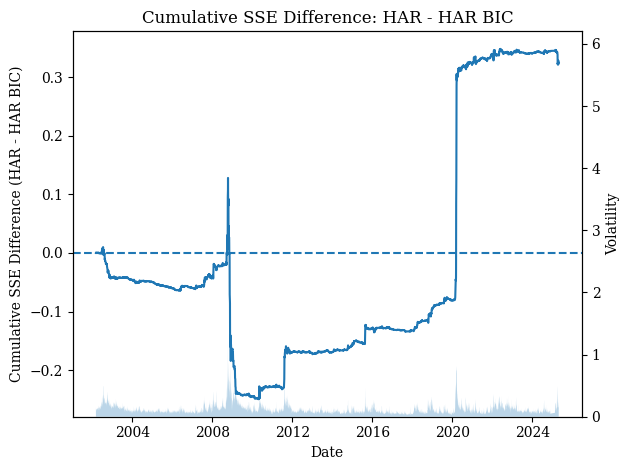

In [12]:
df_a = load_forecast_csv(file_a)
df_b = load_forecast_csv(file_b)
res = cumulative_sse_difference(df_a, df_b)

print(f"Total SSE ({label_a}): {res['SE_A'].sum():,.6f}")
print(f"Total SSE ({label_b}): {res['SE_B'].sum():,.6f}")
print(f"Final Cumulative Difference (A - B): {res['CumDiff'].iloc[-1]:,.6f}")

plot_cumulative_difference_with_vol(
    res, label_a=label_a, label_b=label_b, vol_height_frac=vol_height_frac
)